# 02 – STL Decomposition Effect

**Questions answered:**
- Which family benefits most / is harmed most by STL decomposition?
- Does the STL effect change between Monthly and Quarterly data?
- Does POCID show a tradeoff where decomposition lowers error but hurts directionality?
- Are Wilcoxon tests statistically significant?

**Requires:** `data/master_metrics.parquet` and `data/stl_delta.parquet` from notebook 01.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
DATA = Path("data")

master = pd.read_parquet(DATA / "master_metrics.parquet")
stl_delta = pd.read_parquet(DATA / "stl_delta.parquet")

DECOMP_ORDER = ["without_stl", "stl_seasonal_naive", "stl_model_all_components"]
DECOMP_LABELS = {
    "without_stl": "Direct",
    "stl_seasonal_naive": "STL–SeasonalNaive",
    "stl_model_all_components": "STL–AllComponents",
}
FAMILY_ORDER = ["statistical", "mlforecast", "neuralforecast", "transformers"]
FAMILY_LABELS = {
    "statistical": "Statistical",
    "mlforecast": "ML",
    "neuralforecast": "Neural",
    "transformers": "Transformers",
}

def relabel(series, mapping):
    return series.map(mapping).fillna(series)

print("Loaded. master:", master.shape, "  stl_delta:", stl_delta.shape)

Loaded. master: (3382722, 31)   stl_delta: (2255148, 35)


## Overall RelNaive by Decomposition Strategy

Aggregated over all features, frequencies, model families, and finetuning modes.

In [2]:
overall = (
    master
    .groupby("decomposition_method", as_index=False)
    .agg(
        mean_rn=("rel_naive_clipped", "mean"),
        median_rn=("rel_naive_clipped", "median"),
        mean_pocid=("pocid", "mean"),
        n_rows=("rel_naive_clipped", "count"),
    )
    .sort_values("mean_rn")
)
overall["decomposition_method"] = relabel(overall["decomposition_method"], DECOMP_LABELS)
print(overall.to_string(index=False))

decomposition_method  mean_rn  median_rn  mean_pocid  n_rows
              Direct 1.056805   0.995521    0.587798 1127574
   STL–SeasonalNaive 1.065331   0.941737    0.603994 1127574
   STL–AllComponents 1.082034   0.910516    0.606458 1127574


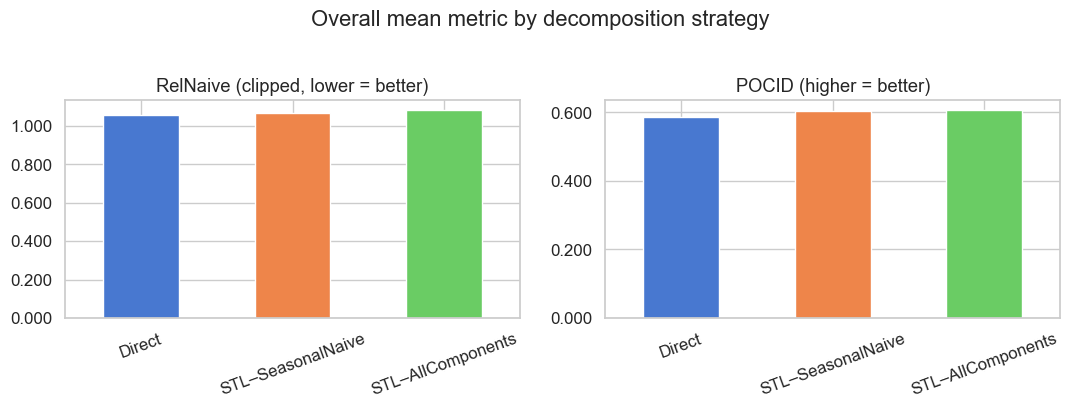

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, label in zip(axes,
                              ["rel_naive_clipped", "pocid"],
                              ["RelNaive (clipped, lower = better)", "POCID (higher = better)"]):
    grp = (
        master
        .groupby("decomposition_method")[metric]
        .mean()
        .reindex(DECOMP_ORDER)
    )
    grp.index = [DECOMP_LABELS[d] for d in grp.index]
    grp.plot(kind="bar", ax=ax, color=sns.color_palette("muted", 3), edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

fig.suptitle("Overall mean metric by decomposition strategy", y=1.02)
fig.tight_layout()
plt.savefig(DATA / "fig_overall_decomp.png", dpi=150, bbox_inches="tight")
plt.show()

## Monthly vs Quarterly

**Q: Does the STL effect change between Monthly and Quarterly data?**

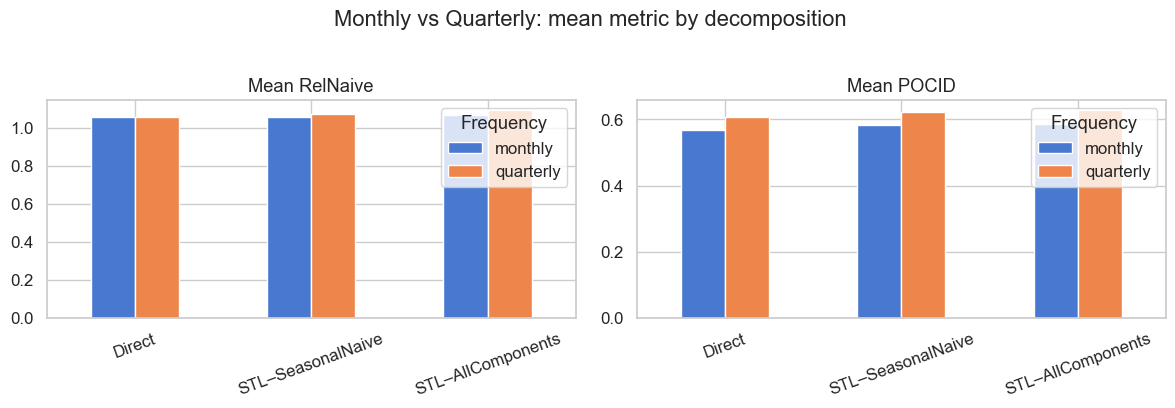

                         mean_pocid           mean_rn          
frequency                   monthly quarterly monthly quarterly
decomposition_method                                           
stl_model_all_components     0.5852    0.6279  1.0707    1.0935
stl_seasonal_naive           0.5847    0.6235  1.0592    1.0715
without_stl                  0.5673    0.6085  1.0575    1.0561


In [4]:
freq_decomp = (
    master
    .groupby(["frequency", "decomposition_method"], as_index=False)
    .agg(mean_rn=("rel_naive_clipped", "mean"), mean_pocid=("pocid", "mean"))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, metric, title in zip(axes,
                              ["mean_rn", "mean_pocid"],
                              ["Mean RelNaive", "Mean POCID"]):
    pivot = freq_decomp.pivot(index="decomposition_method", columns="frequency", values=metric)
    pivot = pivot.reindex(DECOMP_ORDER)
    pivot.index = [DECOMP_LABELS[d] for d in pivot.index]
    pivot.plot(kind="bar", ax=ax, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Frequency")

fig.suptitle("Monthly vs Quarterly: mean metric by decomposition", y=1.02)
fig.tight_layout()
plt.savefig(DATA / "fig_freq_decomp.png", dpi=150, bbox_inches="tight")
plt.show()

print(freq_decomp.pivot_table(index="decomposition_method", columns="frequency",
                              values=["mean_rn", "mean_pocid"]).round(4).to_string())

## Family-Level Decomposition Effect

**Q: Which family benefits most / is harmed most by STL?**

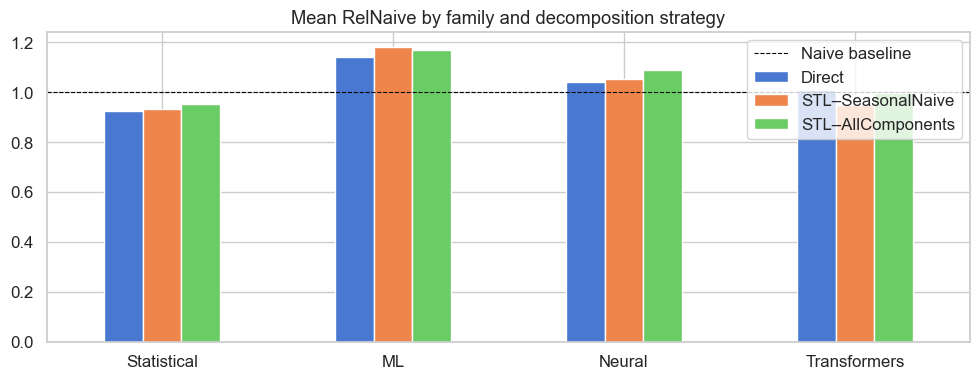


RelNaive by family × decomposition:
              Direct  STL–SeasonalNaive  STL–AllComponents
Statistical   0.9234             0.9321             0.9514
ML            1.1417             1.1824             1.1679
Neural        1.0411             1.0530             1.0897
Transformers  1.0107             0.9496             0.9966


In [5]:
# Mean RelNaive: family × decomposition
fam_decomp = (
    master
    .groupby(["model_family", "decomposition_method"], as_index=False)
    .agg(mean_rn=("rel_naive_clipped", "mean"), mean_pocid=("pocid", "mean"))
)

pivot_rn = fam_decomp.pivot(index="model_family", columns="decomposition_method", values="mean_rn")
pivot_rn = pivot_rn.reindex(FAMILY_ORDER)[DECOMP_ORDER]
pivot_rn.index = [FAMILY_LABELS[f] for f in pivot_rn.index]
pivot_rn.columns = [DECOMP_LABELS[d] for d in pivot_rn.columns]

fig, ax = plt.subplots(figsize=(10, 4))
pivot_rn.plot(kind="bar", ax=ax, edgecolor="white")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="Naive baseline")
ax.set_title("Mean RelNaive by family and decomposition strategy")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper right")
fig.tight_layout()
plt.savefig(DATA / "fig_family_decomp_rn.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRelNaive by family × decomposition:")
print(pivot_rn.round(4).to_string())

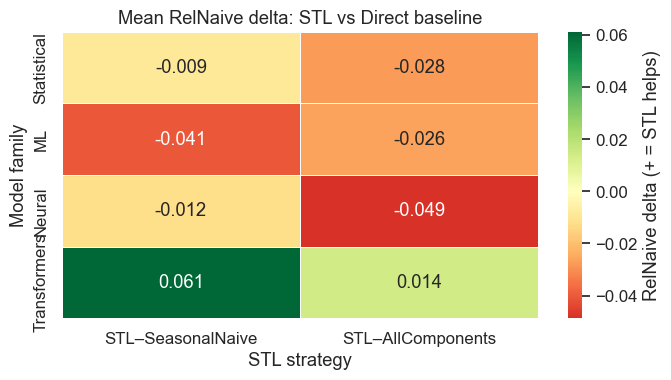


Top 3 benefiting configurations (family × decomp):
model_family     decomposition_method  mean_rn_delta
transformers       stl_seasonal_naive       0.061097
transformers stl_model_all_components       0.014013
 statistical       stl_seasonal_naive      -0.008706

Top 3 harmed configurations:
  model_family     decomposition_method  mean_rn_delta
neuralforecast stl_model_all_components      -0.048671
    mlforecast       stl_seasonal_naive      -0.040697
   statistical stl_model_all_components      -0.028032


In [6]:
# STL benefit heatmap using stl_delta
fam_delta = (
    stl_delta
    .groupby(["model_family", "decomposition_method"], as_index=False)
    .agg(mean_rn_delta=("rn_delta", "mean"))
)
pivot_delta = fam_delta.pivot(index="model_family", columns="decomposition_method", values="mean_rn_delta")
stl_cols = [c for c in ["stl_seasonal_naive", "stl_model_all_components"] if c in pivot_delta.columns]
pivot_delta = pivot_delta.reindex(FAMILY_ORDER)[stl_cols]
pivot_delta.index = [FAMILY_LABELS[f] for f in pivot_delta.index]
pivot_delta.columns = [DECOMP_LABELS[d] for d in pivot_delta.columns]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_delta, annot=True, fmt=".3f", center=0,
    cmap="RdYlGn", linewidths=0.5, ax=ax,
    cbar_kws={"label": "RelNaive delta (+ = STL helps)"}
)
ax.set_title("Mean RelNaive delta: STL vs Direct baseline")
ax.set_xlabel("STL strategy")
ax.set_ylabel("Model family")
fig.tight_layout()
plt.savefig(DATA / "fig_family_stl_delta_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 3 benefiting configurations (family × decomp):")
top = fam_delta.nlargest(3, "mean_rn_delta")[["model_family", "decomposition_method", "mean_rn_delta"]]
print(top.to_string(index=False))
print("\nTop 3 harmed configurations:")
bot = fam_delta.nsmallest(3, "mean_rn_delta")[["model_family", "decomposition_method", "mean_rn_delta"]]
print(bot.to_string(index=False))

## Monthly vs Quarterly Split by Family

**Q: Do the same model families win for Monthly and Quarterly data?**

In [7]:
best_by_freq_family = (
    master
    .groupby(["frequency", "model_family", "decomposition_method"], as_index=False)
    .agg(mean_rn=("rel_naive_clipped", "mean"))
    .sort_values(["frequency", "mean_rn"])
)

for freq in ["monthly", "quarterly"]:
    sub = best_by_freq_family[best_by_freq_family["frequency"] == freq].head(6)
    sub = sub.copy()
    sub["decomposition_method"] = relabel(sub["decomposition_method"], DECOMP_LABELS)
    sub["model_family"] = relabel(sub["model_family"], FAMILY_LABELS)
    print(f"\n── {freq.capitalize()} ── (top 6 family×decomp by RelNaive)")
    print(sub.to_string(index=False))


── Monthly ── (top 6 family×decomp by RelNaive)
frequency model_family decomposition_method  mean_rn
  monthly  Statistical               Direct 0.914806
  monthly  Statistical    STL–SeasonalNaive 0.946827
  monthly Transformers    STL–SeasonalNaive 0.956519
  monthly  Statistical    STL–AllComponents 0.959583
  monthly Transformers    STL–AllComponents 0.996903
  monthly Transformers               Direct 1.005996

── Quarterly ── (top 6 family×decomp by RelNaive)
frequency model_family decomposition_method  mean_rn
quarterly  Statistical    STL–SeasonalNaive 0.917138
quarterly  Statistical               Direct 0.932013
quarterly Transformers    STL–SeasonalNaive 0.942528
quarterly  Statistical    STL–AllComponents 0.943107
quarterly Transformers    STL–AllComponents 0.996388
quarterly Transformers               Direct 1.015378


## POCID Tradeoff

**Q: Does STL lower error but hurt directionality?**

Scatter plot of `rn_delta` vs `pocid_delta` per series.  
Upper-right quadrant: STL helps on both metrics.  
Lower-right quadrant: STL reduces error but hurts direction accuracy.

  STL–SeasonalNaive | ↗ both+: 116,617
  STL–SeasonalNaive | → error+,dir-: 449,024
  STL–SeasonalNaive | ↑ dir+,err-: 116,617
  STL–SeasonalNaive | ↙ both-: 445,316
  STL–AllComponents | ↗ both+: 97,387
  STL–AllComponents | → error+,dir-: 500,992
  STL–AllComponents | ↑ dir+,err-: 74,587
  STL–AllComponents | ↙ both-: 454,608


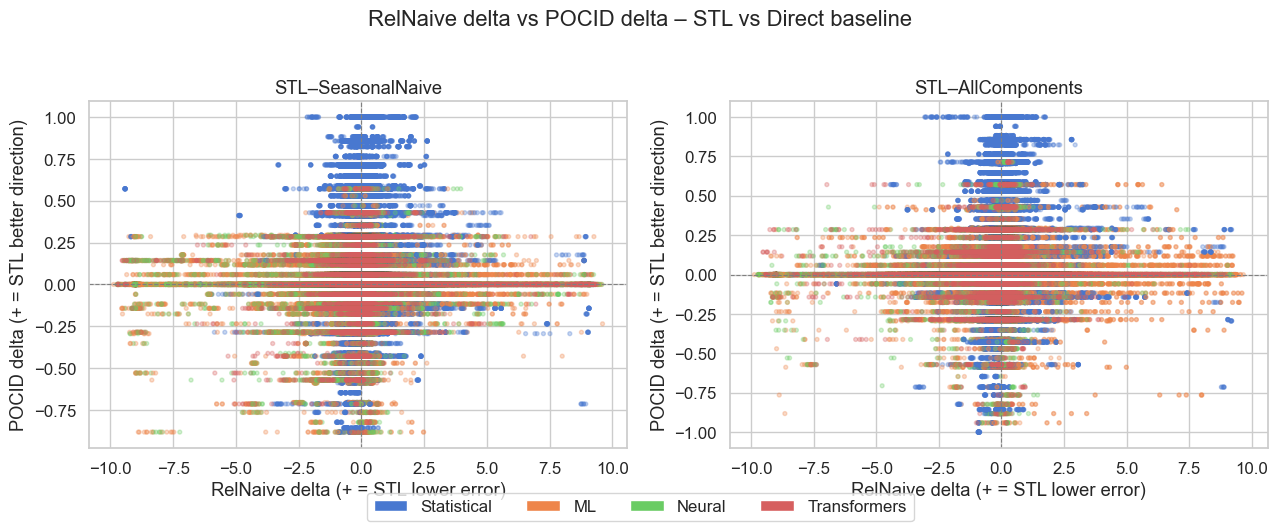

In [8]:
tradeoff = stl_delta.dropna(subset=["rn_delta", "pocid_delta"])

if len(tradeoff) == 0:
    print("POCID data not available – skipping tradeoff scatter.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, decomp in zip(axes, ["stl_seasonal_naive", "stl_model_all_components"]):
        sub = tradeoff[tradeoff["decomposition_method"] == decomp]
        if sub.empty:
            ax.set_visible(False)
            continue
        ax.scatter(sub["rn_delta"], sub["pocid_delta"],
                   alpha=0.3, s=8, c=sub["model_family"].map(
                       {f: c for f, c in zip(FAMILY_ORDER, sns.color_palette("muted", 4))}),
                   rasterized=True)
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_xlabel("RelNaive delta (+ = STL lower error)")
        ax.set_ylabel("POCID delta (+ = STL better direction)")
        ax.set_title(DECOMP_LABELS[decomp])
        # Quadrant counts
        q = [
            (sub["rn_delta"] > 0) & (sub["pocid_delta"] > 0),   # both help
            (sub["rn_delta"] > 0) & (sub["pocid_delta"] <= 0),  # error down, direction worse
            (sub["rn_delta"] <= 0) & (sub["pocid_delta"] > 0),  # direction up, error worse
            (sub["rn_delta"] <= 0) & (sub["pocid_delta"] <= 0), # both harm
        ]
        labels = ["↗ both+", "→ error+,dir-", "↑ dir+,err-", "↙ both-"]
        for mask, lbl in zip(q, labels):
            print(f"  {DECOMP_LABELS[decomp]} | {lbl}: {mask.sum():,}")

    # Legend patches
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=c, label=FAMILY_LABELS[f])
               for f, c in zip(FAMILY_ORDER, sns.color_palette("muted", 4))]
    fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("RelNaive delta vs POCID delta – STL vs Direct baseline", y=1.02)
    fig.tight_layout()
    plt.savefig(DATA / "fig_pocid_tradeoff.png", dpi=150, bbox_inches="tight")
    plt.show()

## Wilcoxon Signed-Rank Tests

Paired test per `(model_family, model_name)`: `stl_variant` vs `without_stl` on RelNaive.  
Positive `mean_improvement` → STL helps.  
Holm correction applied across the family of tests.

In [9]:
from statsmodels.stats.multitest import multipletests

results = []
for (family, model, decomp), grp in stl_delta.groupby(
    ["model_family", "model_name", "decomposition_method"]):
    deltas = grp["rn_delta"].dropna()
    if len(deltas) < 10:
        continue
    try:
        stat, p = wilcoxon(deltas)
    except Exception:
        continue
    results.append({
        "model_family": family,
        "model_name": model,
        "decomposition": DECOMP_LABELS.get(decomp, decomp),
        "n": len(deltas),
        "mean_delta": deltas.mean(),
        "wilcoxon_stat": stat,
        "p_raw": p,
    })

wtest = pd.DataFrame(results)
if len(wtest):
    reject, p_holm, _, _ = multipletests(wtest["p_raw"], method="holm")
    wtest["p_holm"] = p_holm
    wtest["significant"] = reject
    wtest["direction"] = wtest["mean_delta"].apply(lambda x: "STL helps" if x > 0 else "STL harms")
    wtest = wtest.sort_values("p_holm")

    sig = wtest[wtest["significant"]]
    print(f"Significant tests (Holm p < 0.05): {len(sig)} / {len(wtest)}")
    print()
    print("All significant results:")
    print(sig[["model_family", "model_name", "decomposition",
               "n", "mean_delta", "p_holm", "direction"]].to_string(index=False))
else:
    print("No valid Wilcoxon tests (insufficient data).")

Significant tests (Holm p < 0.05): 24 / 24

All significant results:
  model_family           model_name     decomposition      n  mean_delta        p_holm direction
    mlforecast AutoLinearRegression STL–AllComponents 107388    0.153220  0.000000e+00 STL helps
    mlforecast AutoLinearRegression STL–SeasonalNaive 107388    0.098648  0.000000e+00 STL helps
    mlforecast     AutoRandomForest STL–AllComponents 107388   -0.199044  0.000000e+00 STL harms
    mlforecast     AutoRandomForest STL–SeasonalNaive 107388   -0.178684  0.000000e+00 STL harms
    mlforecast            AutoRidge STL–AllComponents 107388    0.154142  0.000000e+00 STL helps
    mlforecast            AutoRidge STL–SeasonalNaive 107388    0.099184  0.000000e+00 STL helps
    mlforecast          AutoXGBoost STL–AllComponents 107388   -0.213189  0.000000e+00 STL harms
    mlforecast          AutoXGBoost STL–SeasonalNaive 107388   -0.181934  0.000000e+00 STL harms
neuralforecast             AutoLSTM STL–AllComponents 1073

C:\Users\diogo\AppData\Local\Temp\ipykernel_25328\2520102201.py:16: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_25328\2520102201.py:16: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\ipykernel_25328\2520102201.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(DATA / "fig_wilcoxon_stl.png", dpi=150, bbox_inches="tight")
C:\Users\diogo\AppData\Local\Temp\ipykernel_25328\2520102201.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(DATA / "fig_wilcoxon_stl.png", dpi=150, bbox_inches="tight")
c:\Users\diogo\Documents\MIA_UP\BolsaIA\TimeSeriesForecasting\Trabalho\.time_series\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw

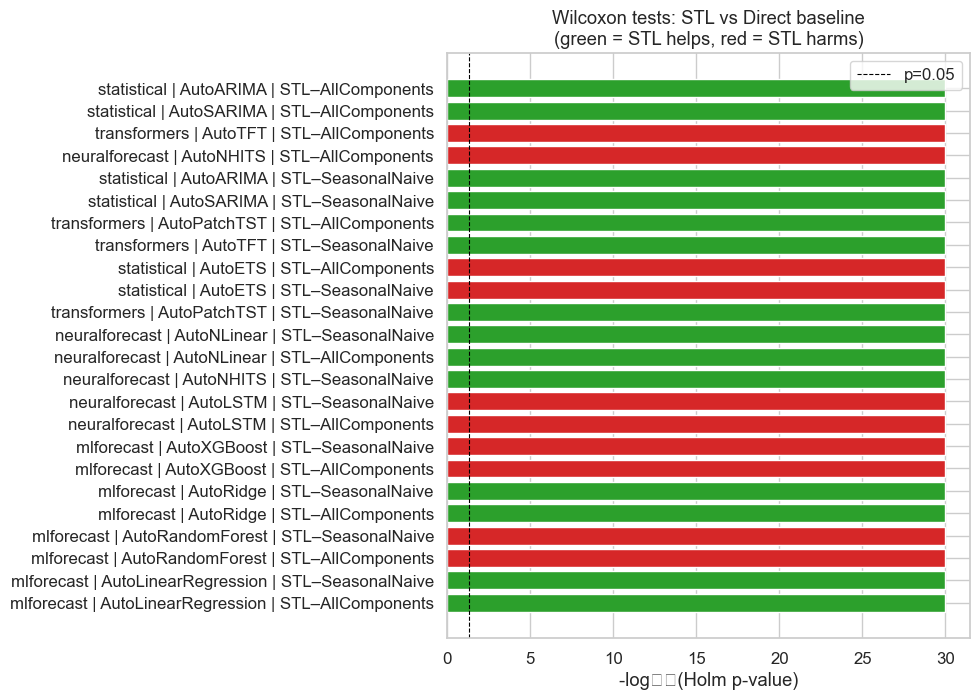

In [10]:
# Visualise significance
if len(wtest) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(wtest) * 0.3)))
    plot_data = wtest.copy()
    plot_data["-log10(p)"] = -np.log10(plot_data["p_holm"].clip(1e-30))
    plot_data["label"] = plot_data["model_family"] + " | " + plot_data["model_name"] + " | " + plot_data["decomposition"]
    colors = plot_data.apply(
        lambda r: ("#2ca02c" if r["mean_delta"] > 0 else "#d62728") if r["significant"] else "#aec7e8",
        axis=1
    )
    ax.barh(plot_data["label"], plot_data["-log10(p)"], color=colors)
    ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8, label="p=0.05")
    ax.set_xlabel("-log₁₀(Holm p-value)")
    ax.set_title("Wilcoxon tests: STL vs Direct baseline\n(green = STL helps, red = STL harms)")
    ax.legend()
    fig.tight_layout()
    plt.savefig(DATA / "fig_wilcoxon_stl.png", dpi=150, bbox_inches="tight")
    plt.show()

## Summary Table

In [11]:
summary = (
    stl_delta
    .groupby(["model_family", "decomposition_method"])
    .agg(
        mean_rn_delta=("rn_delta", "mean"),
        pct_helped=("rn_delta", lambda x: (x > 0).mean() * 100),
        mean_pocid_delta=("pocid_delta", "mean"),
    )
    .reset_index()
    .sort_values("mean_rn_delta", ascending=False)
)
summary["decomposition_method"] = relabel(summary["decomposition_method"], DECOMP_LABELS)
summary["model_family"] = relabel(summary["model_family"], FAMILY_LABELS)
summary.columns = ["Family", "Decomposition", "Mean RelNaive Δ", "% Series Helped", "Mean POCID Δ"]
summary["Mean RelNaive Δ"] = summary["Mean RelNaive Δ"].round(4)
summary["% Series Helped"] = summary["% Series Helped"].round(1)
summary["Mean POCID Δ"] = summary["Mean POCID Δ"].round(4)
summary.to_csv(DATA / "table_decomp_summary.csv", index=False)
summary

,Family,Decomposition,Mean RelNaive Δ,% Series Helped,Mean POCID Δ
7,Transformers,STL–SeasonalNaive,0.0611,57.6,0.0051
6,Transformers,STL–AllComponents,0.0140,59.6,0.0085
5,Statistical,STL–SeasonalNaive,-0.0087,37.1,0.0857
3,Neural,STL–SeasonalNaive,-0.0120,52.2,0.0045
0,ML,STL–AllComponents,-0.0262,53.1,0.0064
4,Statistical,STL–AllComponents,-0.0280,39.8,0.0897
1,ML,STL–SeasonalNaive,-0.0407,49.8,0.0045
2,Neural,STL–AllComponents,-0.0487,55.3,0.0063
